In [2]:
from helpers.ml import (get_training_logger, 
                        train_models_for_target, 
                        cluster_and_split,
                        LogTransformer)
from helpers.preprocessors import load_dict_from_file
from helpers.plotters import plot_observed_vs_predicted

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS  # For distinct colors

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    GroupKFold,
    GroupShuffleSplit, 
    train_test_split
)
from sklearn.linear_model import BayesianRidge, ElasticNet
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

import random
import os
import joblib

In [18]:
SSL_FOLDER = '../doukkala_ssl_datasets_apriori'
# List all CSV files in the 'doukkala_ssl_datasets' directory
csv_files = [f for f in os.listdir(SSL_FOLDER) if f.endswith('.csv')]
print(csv_files)

['merged_doukkala_raw_spectra_apriori.csv']


In [19]:
merged_dataset = pd.read_csv(os.path.join(SSL_FOLDER, csv_files[0]))

In [20]:
# ---------------------------
# Constants and Settings
# ---------------------------
RANDOM_SEED = 42 #random.randint(0, 1000000)
ENABLE_HYPERPARAMETER_TUNING = False
USE_BAYES_OPT = True
USE_RFE = False
USE_GROUP_SPLIT = True  # Set to False for simple train-test split
TEST_SIZE = 0.2
SPLIT_STRATEGY = 'groupkfold' # 'kfold', 'groupkfold' or 'stratifiedshuffle'

columns_to_transform = ['Clay%', 'Coarse element %', 'C.E.C (meq / 100g)', 'Na2O ppm', 'Cl- ppm', 
                        'Organic matter%', 'Exchangeable K2O ppm', 'P2O5 ehangable Olsen ppm',
                        'MgO ppm', 'Iron ppm DTPA', 'Mn ppm DTPA']

os.makedirs("final_models", exist_ok=True)
os.makedirs("metrics", exist_ok=True)

In [21]:
# ---------------------------
# Model Pipelines Configuration
# ---------------------------

num_features = 50

model_pipelines = {
    #"PLSRegression": {
    #    "model": PLSRegression(),
    #    "params": {
    #        "model__n_components": np.arange(2, min(21, num_features + 1), 2)
    #    }
    #},
    #"ElasticNet": {
    #    "model": ElasticNet(max_iter=10000),
    #    "params": {
    #        "model__alpha": np.logspace(-4, 0.5, 8),
    #        "model__l1_ratio": np.concatenate([
    #            np.linspace(0.1, 0.5, 3),
    #            np.linspace(0.6, 1.0, 5)
    #        ])
    #    }
    #},
    "BayesianRidge": {
        "model": BayesianRidge(),
        "params": {
            "model__alpha_1": np.logspace(-6, -2, 5),
            "model__alpha_2": np.logspace(-6, -2, 5),
            "model__lambda_1": np.logspace(-6, -2, 5),
            "model__lambda_2": np.logspace(-6, -2, 5)
        }
    },
    #"SVR": {
    #    "model": SVR(),
    #    "params": {
    #        "model__kernel": ["rbf", "linear"],
    #        "model__C": np.logspace(-2, 2, 6),
    #        "model__gamma": ["scale", "auto"],
    #        "model__epsilon": [0.01, 0.1, 0.2]
    #    }
    #},
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=RANDOM_SEED),
        "params": {
            "model__n_estimators": list(range(100, 351, 50)),
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__max_depth": list(range(3, 20, 2)),
            "model__subsample": [0.6, 0.8, 1.0],
            "model__min_samples_split": [2, 5, 10]
        }
    }
}

In [23]:
# ---------------------------
# Logging Configuration
# ---------------------------
logger = get_training_logger(name='AlMoutmir Soil Models Training')
logger.info("Logger initialized successfully.")

# ---------------------------
# Define Columns and Model Pipelines
# ---------------------------
target_columns = ['Sand%', 
                  'Clay%', 
                  'Total_Silt%', 
                  'pH_water', 
                  'CE_ext1 / 5 ms / cm',
                  'C / N ratio', 
                  'Organic matter%', 
                  'Exchangeable K2O ppm', 
                  'P2O5 ehangable Olsen ppm'
                  ]

eliminated = ['uuid', 'Latitude_Y', 'Longitude_X', 'Month', 'Fine silt%', 'Coarse silt%', 'CaCo3%_Total', 'CaO ppm', 
              'Coarse element %', 'CaCo3 active%', 'C.E.C (meq / 100g)', 'Na2O ppm', 'Cl- ppm', 
              'Na meq / 100g', 'MgO ppm', 'Iron ppm DTPA', 'Mn ppm DTPA', 'Cu ppm DTPA', 'Zn ppm DTPA', 'B ppm Hot water',
              #'Elevation', 'GPP', 'ET', 'LST', 'NDVI', 'SU_WRB1_PH', 
              'Slope', 
              #'bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08', 'bio09', 'bio10', 
              #'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19'
              ]
feature_columns = [col for col in merged_dataset.columns if col not in target_columns + eliminated]
#feature_columns = [col for col in merged_dataset.columns if col in eliminated]

# ---------------------------
# KMeans Clustering for Spatial Segmentation
# ---------------------------

logger.info("Clustering dataset based on spatial location (KMeans)...")
merged_df = cluster_and_split(merged_dataset, seed=RANDOM_SEED, n_clusters=12)
logger.info(f"Cluster value counts:\n{merged_df['cluster'].value_counts().to_string()}")

# ---------------------------
# Dataset Splitting
# ---------------------------

# Drop only columns in X that are all NaNs, and drop rows with any NaNs in X
valid_feature_columns = merged_df[feature_columns].dropna(axis=1, how='all').columns.tolist()
X_base = merged_df[valid_feature_columns]

# One-hot encode only the 'SU_WRB1_PH' column
if 'SU_WRB1_PH' in X_base.columns:
    logger.info("One-hot encoding 'SU_WRB1_PH' column...")
    # One-hot encode the 'SU_WRB1_PH' column
    X_base = pd.get_dummies(X_base, columns=['SU_WRB1_PH'])


X_base = X_base.apply(lambda row: row.fillna(row.mean()), axis=1)
merged_cleaned = merged_df.loc[X_base.index]

groups_all = merged_cleaned['cluster']
y_all = merged_cleaned[target_columns]

if USE_GROUP_SPLIT:
    logger.info("Splitting dataset into train and test groups using GroupShuffleSplit...")
    
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
    train_idx, test_idx = next(gss.split(X_base, y_all, groups=groups_all))
    
    X_train_all, X_test_all = X_base.iloc[train_idx], X_base.iloc[test_idx]
    y_train_all, y_test_all = y_all.iloc[train_idx], y_all.iloc[test_idx]
    groups_train_all = groups_all.iloc[train_idx]
    groups_test_all = groups_all.iloc[test_idx]
    
    logger.info("Splitting dataset into train/test groups using GroupShuffleSplit... "
                f"Train: {len(train_idx)} rows | Test: {len(test_idx)} rows")
    
    logger.info(f"Train group distribution:\n{groups_train_all.value_counts().sort_index().to_string()}")
    logger.info(f"Test group distribution:\n{groups_test_all.value_counts().sort_index().to_string()}")
    logger.info(f"Test set includes groups: {sorted(groups_test_all.unique())}")
else:
    logger.info("Splitting dataset using simple train-test split...")
    
    X_train_all, X_test_all, y_train_all, y_test_all, groups_train_all, groups_test_all = train_test_split(
        X_base, y_all, groups_all, test_size=TEST_SIZE, random_state=RANDOM_SEED
    )
    
    logger.info("Splitting dataset using simple train-test split... "
                f"Train: {len(X_train_all)} rows | Test: {len(X_test_all)} rows")
    
    logger.info(f"Train group distribution:\n{groups_train_all.value_counts().sort_index().to_string()}")
    logger.info(f"Test group distribution:\n{groups_test_all.value_counts().sort_index().to_string()}")



2025-06-10 12:06:33,109 - AlMoutmir Soil Models Training - INFO - Logger initialized successfully.
2025-06-10 12:06:33,113 - AlMoutmir Soil Models Training - INFO - Clustering dataset based on spatial location (KMeans)...


[INFO] Starting KMeans clustering for spatial segmentation.
[INFO] Clustering completed successfully.


2025-06-10 12:06:33,363 - AlMoutmir Soil Models Training - INFO - Cluster value counts:
cluster
5.0     144
9.0     138
3.0     138
10.0    132
11.0    118
6.0     106
1.0     102
2.0      80
8.0      70
12.0     68
7.0      57
4.0      54
2025-06-10 12:06:33,374 - AlMoutmir Soil Models Training - INFO - One-hot encoding 'SU_WRB1_PH' column...
2025-06-10 12:06:33,758 - AlMoutmir Soil Models Training - INFO - Splitting dataset into train and test groups using GroupShuffleSplit...
2025-06-10 12:06:33,773 - AlMoutmir Soil Models Training - INFO - Splitting dataset into train/test groups using GroupShuffleSplit... Train: 855 rows | Test: 352 rows
2025-06-10 12:06:33,776 - AlMoutmir Soil Models Training - INFO - Train group distribution:
cluster
2.0      80
3.0     138
4.0      54
5.0     144
6.0     106
7.0      57
8.0      70
9.0     138
12.0     68
2025-06-10 12:06:33,778 - AlMoutmir Soil Models Training - INFO - Test group distribution:
cluster
1.0     102
10.0    132
11.0    118
2025-0

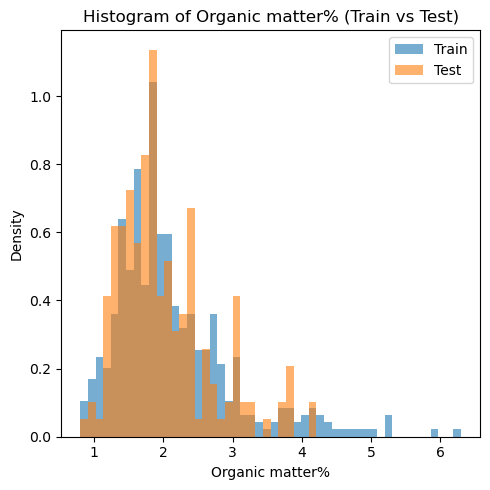

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Drop NaNs
train_data = y_train_all['Organic matter%'].dropna()
test_data = y_test_all['Organic matter%'].dropna()

# Combine to get consistent bins
combined_data = np.concatenate([train_data, test_data])

# Define bins based on combined data
bins = np.histogram_bin_edges(combined_data, bins=50)

plt.figure(figsize=(5, 5))
plt.hist(train_data, bins=bins, alpha=0.6, label='Train', color='tab:blue', density=True)
plt.hist(test_data, bins=bins, alpha=0.6, label='Test', color='tab:orange', density=True)
plt.xlabel('Organic matter%')
plt.ylabel('Density')
plt.title('Histogram of Organic matter% (Train vs Test)')
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
feature_columns

['Aridity_Index',
 'ET',
 'Elevation',
 'GPP',
 'LST',
 'NDVI',
 'SU_WRB1_PH',
 'TWI',
 'bio01',
 'bio02',
 'bio03',
 'bio04',
 'bio05',
 'bio06',
 'bio07',
 'bio08',
 'bio09',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19',
 'Band_1',
 'Band_2',
 'Band_3',
 'Band_4',
 'Band_5',
 'Band_6',
 'Band_7',
 'Band_8',
 'Band_9',
 'Band_10',
 'Band_11',
 'Band_12',
 'Band_13',
 'Band_14',
 'Band_15',
 'Band_16',
 'Band_17',
 'Band_18',
 'Band_19',
 'Band_20',
 'Band_21',
 'Band_22',
 'Band_23',
 'Band_24',
 'Band_25',
 'Band_26',
 'Band_27',
 'Band_28',
 'Band_29',
 'Band_30',
 'Band_31',
 'Band_32',
 'Band_33',
 'Band_34',
 'Band_35',
 'Band_36',
 'Band_37',
 'Band_38',
 'Band_39',
 'Band_40',
 'Band_41',
 'Band_42',
 'Band_43',
 'Band_44',
 'Band_45',
 'Band_46',
 'Band_47',
 'Band_48',
 'Band_49',
 'Band_50',
 'Band_51',
 'Band_52',
 'Band_53',
 'Band_54',
 'Band_55',
 'Band_56',
 'Band_57',
 'Band_58',
 'Band_59',
 'Band_60',
 'Band_61',


In [26]:
# ---------------------------
# Run Training for All Targets
# ---------------------------
logger.info("Starting full training process for all targets...")
all_results = []
for target in target_columns:
    res = train_models_for_target(
            target=target,
            X_train=X_train_all,
            y_train=y_train_all[target],
            X_test=X_test_all,
            y_test=y_test_all[target],
            groups_train=groups_train_all,
            model_pipelines=model_pipelines,
            columns_to_transform=columns_to_transform,
            seed=RANDOM_SEED,
            split_strategy=SPLIT_STRATEGY,
            enable_hyperparameter_tuning=ENABLE_HYPERPARAMETER_TUNING, 
            use_bayes_opt=USE_BAYES_OPT,
            enable_rfe= USE_RFE
        )
    if res:
        all_results.extend(res)

# ---------------------------
# Save and Display Final Metrics
# ---------------------------
metrics_df = pd.DataFrame(all_results)
top_models = metrics_df.groupby("target").apply(lambda df: df.sort_values("Test_R2", ascending=False).head(1))
top_models.to_csv("metrics/best_models_summary.csv", index=False)
metrics_df.to_csv("metrics/all_models_metrics.csv", index=False)
logger.info("Metrics saved to metrics/all_models_metrics.csv")
print("\nFinal Metrics DataFrame:")

joblib.dump({
    "X_test": X_test_all,
    "y_test": y_test_all
}, "final_models/test_sets.pkl")
logger.info("Test sets saved to final_models/test_sets.pkl")

# Display the metrics DataFrame
display(metrics_df)

2025-06-10 12:06:50,775 - AlMoutmir Soil Models Training - INFO - Starting full training process for all targets...


[INFO] Training for target: Sand% — 733 train samples, 250 test samples.
[INFO] Training BayesianRidge for Sand%
[INFO] Fold 1 — Validation groups: [5.0]
[INFO] Fold 2 — Validation groups: [9.0]
[INFO] Fold 3 — Validation groups: [3.0, 12.0]
[INFO] Fold 4 — Validation groups: [2.0, 4.0, 8.0]
[INFO] Fold 5 — Validation groups: [6.0, 7.0]
[INFO] 🏁 BayesianRidge | Sand% — CV RMSE: 22.2462, Test RMSE: 22.6871, R²: -0.0730
[INFO] Saved model to final_models/Sand%_BayesianRidge.pkl and metrics to metrics/Sand%_BayesianRidge_metrics.csv
[INFO] Training GradientBoosting for Sand%
[INFO] Fold 1 — Validation groups: [5.0]
[INFO] Fold 2 — Validation groups: [9.0]
[INFO] Fold 3 — Validation groups: [3.0, 12.0]
[INFO] Fold 4 — Validation groups: [2.0, 4.0, 8.0]
[INFO] Fold 5 — Validation groups: [6.0, 7.0]
[INFO] 🏁 GradientBoosting | Sand% — CV RMSE: 22.0224, Test RMSE: 21.1693, R²: 0.0658
[INFO] Saved model to final_models/Sand%_GradientBoosting.pkl and metrics to metrics/Sand%_GradientBoosting_me

2025-06-10 12:09:29,902 - AlMoutmir Soil Models Training - INFO - Metrics saved to metrics/all_models_metrics.csv

Final Metrics DataFrame:
2025-06-10 12:09:29,927 - AlMoutmir Soil Models Training - INFO - Test sets saved to final_models/test_sets.pkl


/var/folders/sn/9st0f2sx45v3qxbzgrntvpgr0000gn/T/ipykernel_33715/2607701523.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_models = metrics_df.groupby("target").apply(lambda df: df.sort_values("Test_R2", ascending=False).head(1))


,target,model,Test_RMSE,Test_MAE,Test_R2,CV_RMSE_Mean,CV_RMSE_Std,Test_ExplainedVar,Best_Params
0,Sand%,BayesianRidge,22.687067,17.352177,-0.073008,22.246151,5.337819,-0.017135,Default (no tuning)
1,Sand%,GradientBoosting,21.169259,16.351452,0.065762,22.022372,2.855749,0.089786,Default (no tuning)
2,Clay%,BayesianRidge,29.213971,21.453425,-0.411921,8.298509,1.829953,-0.165179,Default (no tuning)
3,Clay%,GradientBoosting,26.366831,19.331996,-0.150125,8.834009,2.082990,0.035072,Default (no tuning)
4,Total_Silt%,BayesianRidge,13.525378,10.677313,0.027908,13.728759,1.853649,0.029943,Default (no tuning)
5,Total_Silt%,GradientBoosting,14.742618,11.639939,-0.154936,14.827586,1.821489,-0.106085,Default (no tuning)
6,pH_water,BayesianRidge,0.460042,0.360285,-0.164139,0.592720,0.134877,-0.149724,Default (no tuning)
7,pH_water,GradientBoosting,0.493647,0.377025,-0.340426,0.512636,0.073039,-0.288623,Default (no tuning)
8,CE_ext1 / 5 ms / cm,BayesianRidge,0.149425,0.107649,0.110729,0.233890,0.052763,0.122338,Default (no tuning)
9,CE_ext1 / 5 ms / cm,GradientBoosting,0.167308,0.115398,-0.114866,0.242409,0.059928,-0.041379,Default (no tuning)


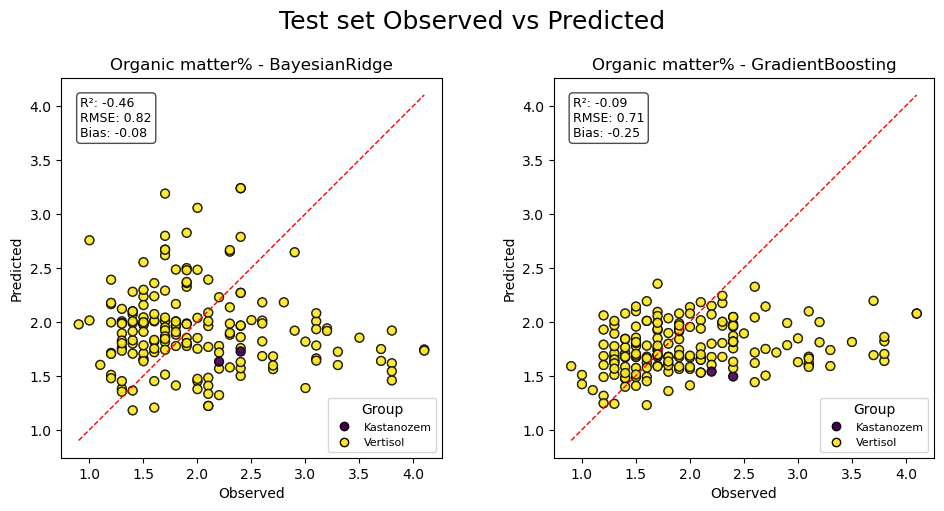

In [ ]:
# Load Soil Groups:
file_path = "soil_groups.txt"
dictionary = load_dict_from_file(file_path)

# Optional: define group label mapping (fuzzy substring match)
group_prefix = "SU_WRB1_PH_"
group_label_map = load_dict_from_file(file_path)

# Load your data
test_sets = joblib.load("final_models/test_sets.pkl")
X_test = test_sets["X_test"]
y_test_dict = test_sets["y_test"]

# Run the plot
plot_observed_vs_predicted(
    X_test=X_test,
    y_test_dict=y_test_dict,
    model_pipelines=model_pipelines,
    target_columns=target_columns,
    columns_to_transform=columns_to_transform,
    log_transformer=LogTransformer(),
    group_prefix=group_prefix,
    group_label_map=group_label_map
)